In [1]:
import os
import torch
import torch.optim as optim
import argparse
from dataloader import *
from model.model import *
import timeit
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score
from utils import *



train_loader, val_loader, test_loader, n_sensors = load_data(dataset="PMU", contaminated = True,
                                                                 window_size=16, stride=10, batch_size =1)
k_ratio = 0.10

k = int(k_ratio * n_sensors)
    # train model

    # create instance of CANF model
wavenf = WaveletEnhancedNF(num_blocks= 1,
                        hidden_d = 32, 
                        wavelet_type = "db2",
                        k = k,
                        N = 16,
                        n_heads = 1,
                        num_features = 1, 
                        st_units = 32, 
                        st_layers = 1,
                        num_entities=n_sensors,
                        wavelet=1,
                        attention=1,
                        b_norm= True, 
                        momentum=0.95)
#wavenf = wavenf.to(device)

model_name = "WaveletNF_PMU_seed_6"
checkpt_path = os.path.join('../checkpoint', model_name)
checkpt_path = checkpt_path + "/best_params.pt"
print("Loading weights from ", checkpt_path)

wavenf.load_state_dict(torch.load(checkpt_path))

                    
                

data length: 644713
(644713, 96)
9330
9321
9158
9285
9091
wavelet: 1
use_attention: 1
Loading weights from  ../checkpoint/WaveletNF_PMU_seed_6/best_params.pt


/home/jbuckelew/anaconda3/envs/canf/lib/python3.11/site-packages/torch/nn/modules/rnn.py:71: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.1 and num_layers=1
  warnings.warn("dropout option adds dropout after all but last "


<All keys matched successfully>

In [2]:

top_k_features = []

cascade_start_idxs = [866,861,870, 863, 859]

with torch.no_grad():
    i = 0
    for x, label, in test_loader[1]:
        # inject random noise to a single feature

        loss = -1 * wavenf(x, take_mean=False).cpu().numpy()
            
        if i >= cascade_start_idxs[0]:
            top_k_feat = wavenf.get_top_k_features()
            top_k_features.append(top_k_feat)
        i +=1





In [68]:
def inject_noise(x):
    random_feature = np.random.randint(0, x.shape[-1])
    
    mean = 0
    std_dev = 5.0
    random_noise = np.random.normal(mean, std_dev, size=x.shape[1])
    x[0, :, random_feature] = x[0, :, random_feature] + random_noise
    return x


class MultiSimulationOverlapAnalyzer:
    """
    Analyze top-k overlaps across multiple simulation runs
    """
    def __init__(self, model, k):
        self.model = model
        self.k = k
        self.all_simulations = []  # Store results from all simulations
        
    def analyze_single_simulation(self, data_loader, cascade_start_idx, 
                                  simulation_id, device='cuda'):
        """
        Analyze a single simulation and store results
        
        Args:
            data_loader: DataLoader for this simulation
            cascade_start_idx: Where cascading begins in this simulation
            simulation_id: Identifier for this simulation (e.g., 0, 1, 2...)
        
        Returns:
            simulation_results: Dict with all analysis results
        """
        print(f"\n{'='*70}")
        print(f"ANALYZING SIMULATION {simulation_id}")
        print(f"{'='*70}")
        
        # Extract top-k selections
        topk_selections = self._extract_topk_selections(data_loader, cascade_start_idx, device)
        
        # Split by anomaly type
        point_selections, cascade_selections = self._split_by_anomaly_type(
            topk_selections, cascade_start_idx
        )
        
        # Compute overlaps for different lags
        results = {
            'simulation_id': simulation_id,
            'cascade_start_idx': cascade_start_idx,
            'num_windows': len(topk_selections),
            'num_point_windows': len(point_selections),
            'num_cascade_windows': len(cascade_selections),
            'point_overlaps': {},
            'cascade_overlaps': {},
            'point_overlap_timeline': None,
            'cascade_overlap_timeline': None,
            'topk_selections': topk_selections,
            'point_selections': point_selections,
            'cascade_selections': cascade_selections
        }
        
        # Compute overlaps for multiple lags
        for delta_t in [1, 2]:
            if len(point_selections) > delta_t:
                point_overlaps = self._compute_overlap_with_lag(point_selections, delta_t)
                results['point_overlaps'][f'delta_t_{delta_t}'] = point_overlaps
            
            if len(cascade_selections) > delta_t:
                cascade_overlaps = self._compute_overlap_with_lag(cascade_selections, delta_t)
                results['cascade_overlaps'][f'delta_t_{delta_t}'] = cascade_overlaps
        
        # Compute timelines (delta_t=1 only)
        if len(point_selections) > 1:
            results['point_overlap_timeline'] = self._compute_overlap_timeline(point_selections)
        if len(cascade_selections) > 1:
            results['cascade_overlap_timeline'] = self._compute_overlap_timeline(cascade_selections)
        
        # Store results
        self.all_simulations.append(results)
        
        print(f"✓ Simulation {simulation_id} analysis complete")
        self._print_simulation_summary(results)
        
        return results
    
    def _extract_topk_selections(self, data_loader, cascade_idx, device):
        """Extract top-k selections from data loader"""
        self.model.eval()
        self.model = self.model.to(device)
        all_topk_selections = []
        
        with torch.no_grad():
            i = 0
            for x, label, in data_loader:
                # inject random noise to a single feature
                if label == 0:
                    x = inject_noise(x)
                x = x.to(device)
                loss = -1 * wavenf(x, take_mean=False).cpu().numpy()
                topk_indices = self.model.get_top_k_features()
                all_topk_selections.append(topk_indices.cpu())
                i +=1
        
        return torch.cat(all_topk_selections, dim=0)
    
    
    def _split_by_anomaly_type(self, topk_selections, cascade_start_idx):
        """Split selections into point and cascade subsets"""
        point_selections = topk_selections[:cascade_start_idx]
        cascade_selections = topk_selections[cascade_start_idx:]
        return point_selections, cascade_selections
    
    def _compute_overlap_with_lag(self, topk_selections, delta_t):
        """Compute overlap with temporal lag"""
        num_windows, k = topk_selections.shape
        overlaps = []
        
        for i in range(num_windows - delta_t):
            set_t = set(topk_selections[i].tolist())
            set_t_plus_delta = set(topk_selections[i + delta_t].tolist())
            overlap = len(set_t & set_t_plus_delta) / k
            overlaps.append(overlap)
        
        return [o for o in overlaps if not np.isnan(o)]
    
    def _compute_overlap_timeline(self, topk_selections):
        """Compute overlap for each consecutive window pair"""
        return self._compute_overlap_with_lag(topk_selections, delta_t=1)
    
    def _print_simulation_summary(self, results):
        """Print summary statistics for a simulation"""
        print(f"\nSummary Statistics:")
        print(f"  Total windows:    {results['num_windows']}")
        print(f"  Point windows:    {results['num_point_windows']}")
        print(f"  Cascade windows:  {results['num_cascade_windows']}")
        
        for delta_t_key in results['point_overlaps'].keys():
            delta_t = int(delta_t_key.split('_')[-1])
            point_overlaps = results['point_overlaps'][delta_t_key]
            cascade_overlaps = results['cascade_overlaps'].get(delta_t_key, [])
            
            if len(point_overlaps) > 0:
                print(f"\n  Point Δt={delta_t}: Mean={np.mean(point_overlaps):.3f}, "
                      f"Std={np.std(point_overlaps):.3f}, N={len(point_overlaps)}")
            if len(cascade_overlaps) > 0:
                print(f"  Cascade Δt={delta_t}: Mean={np.mean(cascade_overlaps):.3f}, "
                      f"Std={np.std(cascade_overlaps):.3f}, N={len(cascade_overlaps)}")
    
    def aggregate_results(self):
        """
        Aggregate results across all simulations
        
        Returns:
            aggregated: Dict with combined statistics
        """
        if len(self.all_simulations) == 0:
            raise ValueError("No simulations analyzed yet!")
        
        print(f"\n{'='*70}")
        print(f"AGGREGATING RESULTS FROM {len(self.all_simulations)} SIMULATIONS")
        print(f"{'='*70}")
        
        aggregated = {
            'num_simulations': len(self.all_simulations),
            'point_overlaps_combined': defaultdict(list),
            'cascade_overlaps_combined': defaultdict(list),
            'point_overlaps_per_sim': defaultdict(list),
            'cascade_overlaps_per_sim': defaultdict(list),
            'statistics': {}
        }
        
        # Combine all overlaps across simulations
        for sim_result in self.all_simulations:
            # Point anomaly overlaps
            for delta_t_key, overlaps in sim_result['point_overlaps'].items():
                aggregated['point_overlaps_combined'][delta_t_key].extend(overlaps)
                aggregated['point_overlaps_per_sim'][delta_t_key].append(overlaps)
            
            # Cascading failure overlaps
            for delta_t_key, overlaps in sim_result['cascade_overlaps'].items():
                aggregated['cascade_overlaps_combined'][delta_t_key].extend(overlaps)
                aggregated['cascade_overlaps_per_sim'][delta_t_key].append(overlaps)
        
        # Compute aggregate statistics
        for delta_t_key in aggregated['point_overlaps_combined'].keys():
            point_overlaps = aggregated['point_overlaps_combined'][delta_t_key]
            cascade_overlaps = aggregated['cascade_overlaps_combined'][delta_t_key]
            
            delta_t = int(delta_t_key.split('_')[-1])
            
            aggregated['statistics'][delta_t_key] = {
                'delta_t': delta_t,
                'point': {
                    'all_values': point_overlaps,
                    'mean': np.mean(point_overlaps),
                    'std': np.std(point_overlaps),
                    'median': np.median(point_overlaps),
                    'min': np.min(point_overlaps),
                    'max': np.max(point_overlaps),
                    'n_samples': len(point_overlaps)
                },
                'cascade': {
                    'all_values': cascade_overlaps,
                    'mean': np.mean(cascade_overlaps),
                    'std': np.std(cascade_overlaps),
                    'median': np.median(cascade_overlaps),
                    'min': np.min(cascade_overlaps),
                    'max': np.max(cascade_overlaps),
                    'n_samples': len(cascade_overlaps)
                }
            }
        
        self._print_aggregated_statistics(aggregated)
        
        return aggregated
    
    def _print_aggregated_statistics(self, aggregated):
        """Print aggregated statistics"""
        print(f"\nAggregated Statistics Across {aggregated['num_simulations']} Simulations:")
        print(f"{'='*70}")
        
        for delta_t_key in sorted(aggregated['statistics'].keys(), 
                                 key=lambda x: int(x.split('_')[-1])):
            delta_t = aggregated['statistics'][delta_t_key]['delta_t']
            point_stats = aggregated['statistics'][delta_t_key]['point']
            cascade_stats = aggregated['statistics'][delta_t_key]['cascade']
            
            print(f"\nΔt = {delta_t}:")
            print(f"  Point Anomalies:")
            print(f"    Mean:   {point_stats['mean']:.4f} ± {point_stats['std']:.4f}")
            print(f"    Median: {point_stats['median']:.4f}")
            print(f"    Range:  [{point_stats['min']:.4f}, {point_stats['max']:.4f}]")
            print(f"    N:      {point_stats['n_samples']}")
            
            print(f"  Cascading Failures:")
            print(f"    Mean:   {cascade_stats['mean']:.4f} ± {cascade_stats['std']:.4f}")
            print(f"    Median: {cascade_stats['median']:.4f}")
            print(f"    Range:  [{cascade_stats['min']:.4f}, {cascade_stats['max']:.4f}]")
            print(f"    N:      {cascade_stats['n_samples']}")
            
            # Difference
            diff = point_stats['mean'] - cascade_stats['mean']
            print(f"  Difference (Point - Cascade): {diff:+.4f}")
        
        print(f"{'='*70}")
    
    def save_results(self, filepath='multi_sim_results.pkl'):
        """Save all results to file"""
        with open(filepath, 'wb') as f:
            pickle.dump({
                'all_simulations': self.all_simulations,
                'k': self.k
            }, f)
        print(f"\n✓ Saved results to {filepath}")
    
    def load_results(self, filepath='multi_sim_results.pkl'):
        """Load results from file"""
        with open(filepath, 'rb') as f:
            data = pickle.load(f)
            self.all_simulations = data['all_simulations']
            self.k = data['k']
        print(f"✓ Loaded results from {filepath}")
        print(f"  Number of simulations: {len(self.all_simulations)}")


def plot_multi_simulation_comparison(aggregated, save_path='multi_sim_comparison.pdf'):
    """
    Create comprehensive plots for multi-simulation results
    
    Args:
        aggregated: Dict from aggregate_results()
    """
    fig = plt.figure(figsize=(14, 6))  # Reduced width since only 2 plots
    gs = fig.add_gridspec(1, 2, hspace=0.3, wspace=0.3)  # Changed to 1 row, 2 columns

    # Prepare data for Δt=1 and Δt=2
    delta_t_keys = [k for k in aggregated['statistics'].keys() 
                    if int(k.split('_')[-1]) <= 2]
    delta_t_keys = sorted(delta_t_keys, key=lambda x: int(x.split('_')[-1]))

    # Plot 1 & 2: Box plots for Δt=1 and Δt=2
    for idx, delta_t_key in enumerate(delta_t_keys[:2]):
        ax = fig.add_subplot(gs[0, idx])  # Changed to gs[0, idx] since now 1 row
        
        delta_t = aggregated['statistics'][delta_t_key]['delta_t']
        point_overlaps = aggregated['statistics'][delta_t_key]['point']['all_values']
        cascade_overlaps = aggregated['statistics'][delta_t_key]['cascade']['all_values']
        
        # Prepare data
        plot_data = []
        for overlap in point_overlaps:
            plot_data.append({'Type': 'Point\nAnomalies', 'Overlap': overlap})
        for overlap in cascade_overlaps:
            plot_data.append({'Type': 'Cascading\nFailures', 'Overlap': overlap})
        
        df = pd.DataFrame(plot_data)
        
        # Box plot
        sns.boxplot(data=df, x='Type', y='Overlap', ax=ax,
                palette=['#3498db', '#e74c3c'], width=0.6)
        
        # Add mean markers
        for i, (anom_type, overlaps) in enumerate([('Point\nAnomalies', point_overlaps),
                                                    ('Cascading\nFailures', cascade_overlaps)]):
            mean_val = np.mean(overlaps)
            ax.plot(i, mean_val, 'D', color='pink', markersize=12, zorder=3)
            ax.text(i, mean_val + 0.05, f'μ={mean_val:.3f}', 
                ha='center', fontsize=10, fontweight='bold', color='pink')
        
        ax.set_xlabel('Anomaly Type', fontsize=12, fontweight='bold')
        ax.set_ylabel('Top-K Overlap Ratio', fontsize=12, fontweight='bold')
        ax.set_title(f'({chr(97+idx)}) Δt={delta_t} (N={aggregated["num_simulations"]} sims)',
                    fontsize=13, fontweight='bold')
        ax.grid(axis='y', alpha=0.3)
        ax.set_ylim([0, 1.05])

    plt.tight_layout()  # Added this for better spacing
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.savefig(save_path.replace('.pdf', '.png'), dpi=300, bbox_inches='tight')
    plt.show()

    print(f"\n✓ Saved multi-simulation plots to {save_path}")






In [69]:
multi_analyzer = MultiSimulationOverlapAnalyzer(model=wavenf, k=k)

# ============================================================================
# Run analysis for each simulation
# ============================================================================
num_simulations = 5
cascade_start_idxs = [866,861,870, 863, 859]
for sim_id in range(num_simulations):
    print(f"\n{'#'*70}")
    print(f"# SIMULATION {sim_id + 1} / {num_simulations}")
    print(f"{'#'*70}")
    
    # Load data for this simulation
    # (You need to create a data loader for each simulation)
    test_loader_sim = test_loader[sim_id]
    
    # Define where cascading starts in THIS simulation
    # This might be different for each simulation!
    cascade_start_idx = cascade_start_idxs[sim_id]  # You define this
    
    # Analyze this simulation
    sim_results = multi_analyzer.analyze_single_simulation(
        data_loader=test_loader_sim,
        cascade_start_idx=cascade_start_idx,
        simulation_id=sim_id,
        device='cuda'
    )




######################################################################
# SIMULATION 1 / 5
######################################################################

ANALYZING SIMULATION 0
✓ Simulation 0 analysis complete

Summary Statistics:
  Total windows:    932
  Point windows:    866
  Cascade windows:  66

  Point Δt=1: Mean=0.501, Std=0.271, N=865
  Cascade Δt=1: Mean=0.328, Std=0.310, N=65

  Point Δt=2: Mean=0.339, Std=0.286, N=864
  Cascade Δt=2: Mean=0.274, Std=0.266, N=64

######################################################################
# SIMULATION 2 / 5
######################################################################

ANALYZING SIMULATION 1
✓ Simulation 1 analysis complete

Summary Statistics:
  Total windows:    931
  Point windows:    861
  Cascade windows:  70

  Point Δt=1: Mean=0.509, Std=0.272, N=860
  Cascade Δt=1: Mean=0.366, Std=0.327, N=69

  Point Δt=2: Mean=0.342, Std=0.286, N=859
  Cascade Δt=2: Mean=0.227, Std=0.285, N=68

#########################

In [70]:
import seaborn as sns
class CascadeProgressionAnalyzer:
    """
    Analyze overlap progression during the early stages of cascading failures
    """
    def __init__(self, multi_analyzer):
        """
        Args:
            multi_analyzer: MultiSimulationOverlapAnalyzer with analyzed simulations
        """
        self.multi_analyzer = multi_analyzer
        self.cascade_progression_results = None
    
    def analyze_cascade_progression(self, num_windows=10):
        """
        Analyze overlap between consecutive windows in early cascade stages
        
        Computes:
        - Window 1→2 overlap (cascade onset)
        - Window 2→3 overlap
        - Window 3→4 overlap
        - ...
        - Window 10→11 overlap
        
        Averaged across all simulations
        
        Args:
            num_windows: Number of consecutive window pairs to analyze (default: 10)
        
        Returns:
            results: Dict with overlaps for each window pair
        """
        print(f"\n{'='*70}")
        print(f"ANALYZING CASCADE PROGRESSION")
        print(f"{'='*70}")
        print(f"Analyzing first {num_windows} consecutive window pairs")
        print(f"Number of simulations: {len(self.multi_analyzer.all_simulations)}")
        print()
        
        # Store overlaps for each window pair across simulations
        progression_overlaps = {
            f'W{i}→W{i+1}': [] for i in range(1, num_windows + 1)
        }
        
        # Process each simulation
        for sim_result in self.multi_analyzer.all_simulations:
            sim_id = sim_result['simulation_id']
            cascade_selections = sim_result['cascade_selections']
            
            if cascade_selections is None or len(cascade_selections) < num_windows + 1:
                print(f"⚠️ Simulation {sim_id}: Not enough cascade windows "
                      f"(has {len(cascade_selections) if cascade_selections is not None else 0}, need {num_windows + 1})")
                continue
            
            k = cascade_selections.shape[1]
            
            print(f"Simulation {sim_id}:")
            
            # Compute overlap for each consecutive pair
            for i in range(num_windows):
                window_a = i      # 0-indexed: 0, 1, 2, ..., 9
                window_b = i + 1  # 0-indexed: 1, 2, 3, ..., 10
                
                # Get feature sets
                set_a = set(cascade_selections[window_a].tolist())
                set_b = set(cascade_selections[window_b].tolist())
                
                # Compute overlap
                overlap = len(set_a & set_b) / k
                
                # Store (using 1-indexed for display)
                key = f'W{i+1}→W{i+2}'
                progression_overlaps[key].append(overlap)
                
                print(f"  {key}: {overlap:.3f}")
        
        # Compute statistics
        self.cascade_progression_results = {
            'overlaps': progression_overlaps,
            'statistics': {},
            'num_windows': num_windows,
            'num_simulations': len(self.multi_analyzer.all_simulations)
        }
        
        print(f"\n{'='*70}")
        print("PROGRESSION STATISTICS")
        print(f"{'='*70}")
        
        for pair_key, overlaps in progression_overlaps.items():
            if len(overlaps) > 0:
                stats = {
                    'overlaps': overlaps,
                    'mean': np.mean(overlaps),
                    'std': np.std(overlaps),
                    'median': np.median(overlaps),
                    'min': np.min(overlaps),
                    'max': np.max(overlaps),
                    'n_samples': len(overlaps)
                }
                self.cascade_progression_results['statistics'][pair_key] = stats
                
                print(f"{pair_key}: Mean={stats['mean']:.3f}, Std={stats['std']:.3f}, N={stats['n_samples']}")
        
        print(f"{'='*70}\n")
        
        return self.cascade_progression_results
    
    def get_onset_overlap(self):
        """
        Get overlap between first and second cascade windows (onset)
        
        Returns:
            overlaps: List of overlap values across simulations
            mean: Mean overlap
            std: Standard deviation
        """
        if self.cascade_progression_results is None:
            raise ValueError("Must run analyze_cascade_progression first!")
        
        onset_key = 'W1→W2'
        stats = self.cascade_progression_results['statistics'][onset_key]
        
        return stats['overlaps'], stats['mean'], stats['std']


def plot_cascade_progression(cascade_results, save_path='cascade_progression.pdf'):
    """
    Create comprehensive visualization of cascade progression overlaps
    
    Args:
        cascade_results: Results from analyze_cascade_progression()
    """
    fig, axes = plt.subplots(1, 2, figsize=(16, 12))
    
    # Prepare data
    progression_overlaps = cascade_results['overlaps']
    statistics = cascade_results['statistics']
    num_windows = cascade_results['num_windows']
    
    # Get ordered keys
    pair_keys = [f'W{i}→W{i+1}' for i in range(1, num_windows + 1)]
    pair_keys = [k for k in pair_keys if k in statistics]  # Only include keys with data
    
    
    # Plot 2: Mean trend line
    ax2 = axes[0]
    
    means = [statistics[k]['mean'] for k in pair_keys]
    stds = [statistics[k]['std'] for k in pair_keys]
    x = range(len(pair_keys))
    
    ax2.plot(x, means, 'o-', linewidth=3, markersize=10,
            color='#e74c3c', label='Mean Overlap', zorder=3)
    ax2.fill_between(x,
                    np.array(means) - np.array(stds),
                    np.array(means) + np.array(stds),
                    alpha=0.3, color='#e74c3c', label='±1 Std')
    
    # Highlight onset
    ax2.axvspan(-0.5, 0.5, alpha=0.2, color='red')
    ax2.text(0, max(means) * 0.95, 'Onset', ha='center', 
            fontsize=11, fontweight='bold',
            bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.7))
    
    # Add horizontal reference line at onset mean
    onset_mean = statistics['W1→W2']['mean']
    ax2.axhline(onset_mean, color='red', linestyle='--', linewidth=2,
               alpha=0.5, label=f'Onset Mean: {onset_mean:.3f}')
    
    ax2.set_xticks(x)
    ax2.set_xticklabels(pair_keys, rotation=45, ha='right', fontsize=10)
    ax2.set_xlabel('Cascade Progression', fontsize=12, fontweight='bold')
    ax2.set_ylabel('Mean Overlap Ratio', fontsize=12, fontweight='bold')
    ax2.set_title('(b) Overlap Trend During Cascade Propagation',
                 fontsize=13, fontweight='bold')
    ax2.legend(fontsize=10, loc='best')
    ax2.grid(True, alpha=0.3)
    ax2.set_ylim([0, 1.05])
    
    # Plot 3: Onset comparison with other stages
    ax3 = axes[1]
    
    # Group: Onset vs Early (2-15) vs Middle (15-30) vs Late/Blackout (30-45)
    onset_overlaps = statistics['W1→W2']['overlaps']

    early_overlaps = []
    for i in range(2, 15):
        key = f'W{i}→W{i+1}'
        if key in statistics:
            early_overlaps.extend(statistics[key]['overlaps'])

    middle_overlaps = []
    for i in range(15, 30):
        key = f'W{i}→W{i+1}'
        if key in statistics:
            middle_overlaps.extend(statistics[key]['overlaps'])

    late_overlaps = []
    for i in range(30, 45):
        key = f'W{i}→W{i+1}'
        if key in statistics:
            late_overlaps.extend(statistics[key]['overlaps'])

    group_data = []
    for o in onset_overlaps:
        group_data.append({'Stage': 'Onset\n(W1→W2)', 'Overlap': o})
    for o in early_overlaps:
        group_data.append({'Stage': 'Early\n(W2-W15)', 'Overlap': o})
    if len(middle_overlaps) > 0:
        for o in middle_overlaps:
            group_data.append({'Stage': 'Middle\n(W15-W30)', 'Overlap': o})
    if len(late_overlaps) > 0:
        for o in late_overlaps:
            group_data.append({'Stage': 'Late/Blackout\n(W30-W45)', 'Overlap': o})

    df_groups = pd.DataFrame(group_data)

    # Use 4 colors now instead of 3
    sns.boxplot(data=df_groups, x='Stage', y='Overlap', ax=ax3,
            palette=['#e74c3c', '#f39c12', '#3498db', '#9b59b6'], width=0.6)

    # Add means
    stages = df_groups['Stage'].unique()
    for i, stage in enumerate(stages):
        stage_data = df_groups[df_groups['Stage'] == stage]['Overlap']
        mean_val = stage_data.mean()
        ax3.plot(i, mean_val, 'D', color='white', markersize=14, zorder=4,
                markeredgecolor='black', markeredgewidth=2)
        ax3.plot(i, mean_val, 'D', color='red', markersize=10, zorder=5)
        ax3.text(i, mean_val + 0.07, f'μ={mean_val:.3f}',
                ha='center', fontsize=11, fontweight='bold',
                bbox=dict(boxstyle='round', facecolor='white', 
                        edgecolor='black', linewidth=1.5))

    ax3.set_xlabel('Cascade Stage', fontsize=12, fontweight='bold')
    ax3.set_ylabel('Top-K Overlap Ratio', fontsize=12, fontweight='bold')
    ax3.set_title('(c) Comparison: Cascade Stages from Onset to Blackout',
                fontsize=13, fontweight='bold')
    ax3.grid(axis='y', alpha=0.3)
    ax3.set_ylim([0, 1.05])
    
    
    
    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.savefig(save_path.replace('.pdf', '.png'), dpi=300, bbox_inches='tight')
    plt.show()
    
    print(f"✓ Saved cascade progression plot to {save_path}")



In [71]:
# ============================================================================
# STEP 2: Analyze cascade progression
# ============================================================================
cascade_analyzer = CascadeProgressionAnalyzer(multi_analyzer)

# Analyze first 10 consecutive window pairs in cascade region
cascade_progression_results = cascade_analyzer.analyze_cascade_progression(num_windows=45)



ANALYZING CASCADE PROGRESSION
Analyzing first 45 consecutive window pairs
Number of simulations: 5

Simulation 0:
  W1→W2: 0.333
  W2→W3: 0.889
  W3→W4: 0.778
  W4→W5: 0.222
  W5→W6: 0.000
  W6→W7: 0.778
  W7→W8: 0.444
  W8→W9: 0.000
  W9→W10: 0.222
  W10→W11: 0.222
  W11→W12: 0.000
  W12→W13: 0.111
  W13→W14: 0.111
  W14→W15: 0.000
  W15→W16: 0.222
  W16→W17: 0.444
  W17→W18: 0.889
  W18→W19: 0.444
  W19→W20: 0.333
  W20→W21: 0.778
  W21→W22: 0.778
  W22→W23: 0.667
  W23→W24: 0.667
  W24→W25: 0.444
  W25→W26: 0.556
  W26→W27: 0.222
  W27→W28: 0.778
  W28→W29: 0.000
  W29→W30: 0.000
  W30→W31: 0.000
  W31→W32: 0.000
  W32→W33: 0.000
  W33→W34: 0.000
  W34→W35: 0.111
  W35→W36: 0.222
  W36→W37: 0.444
  W37→W38: 0.444
  W38→W39: 0.444
  W39→W40: 0.111
  W40→W41: 0.556
  W41→W42: 0.778
  W42→W43: 0.111
  W43→W44: 0.444
  W44→W45: 0.000
  W45→W46: 0.000
Simulation 1:
  W1→W2: 0.222
  W2→W3: 0.000
  W3→W4: 0.778
  W4→W5: 0.889
  W5→W6: 0.000
  W6→W7: 0.667
  W7→W8: 0.222
  W8→W9: 0.333
  W

/tmp/ipykernel_2656842/157748174.py:219: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_groups, x='Stage', y='Overlap', ax=ax3,


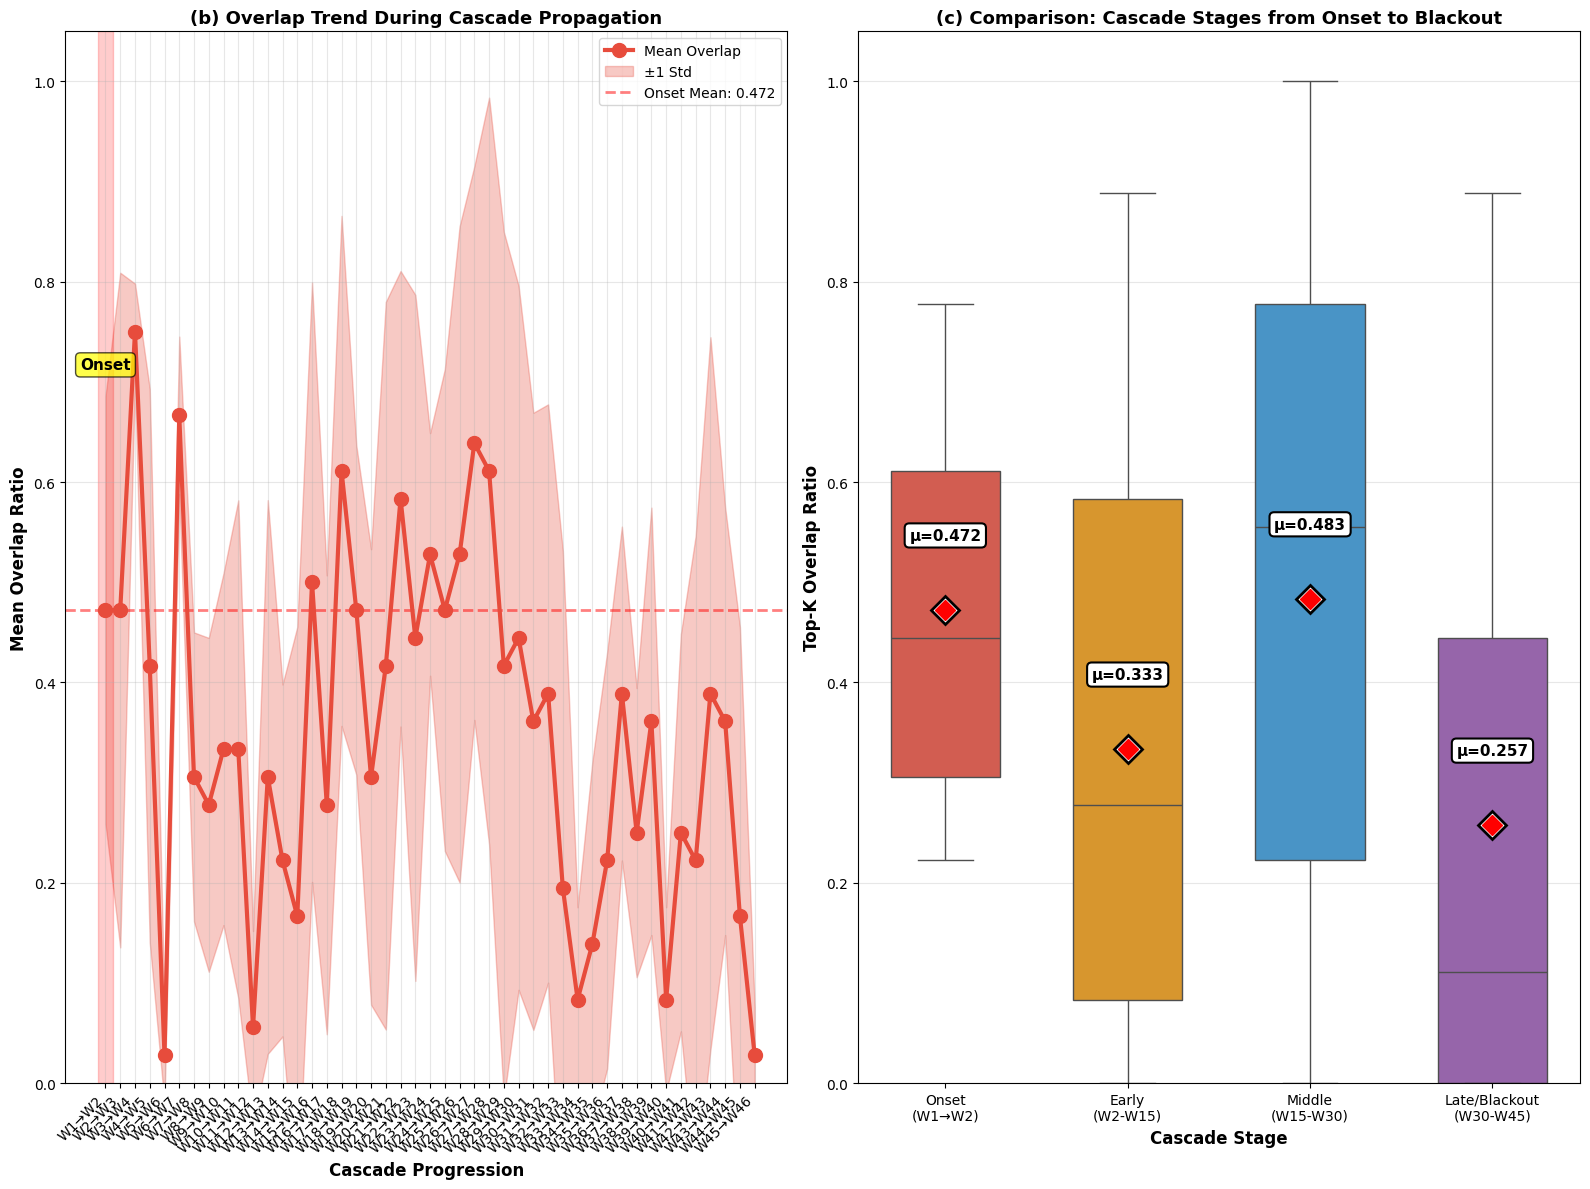

✓ Saved cascade progression plot to cascade_progression.pdf


In [72]:
# ============================================================================
# STEP 3: Get specific results
# ============================================================================

# Get onset overlap (W1→W2)
onset_overlaps, onset_mean, onset_std = cascade_analyzer.get_onset_overlap()




# ============================================================================
# STEP 4: Create visualizations
# ============================================================================

# Comprehensive cascade progression plot
plot_cascade_progression(
    cascade_progression_results,
    save_path='cascade_progression.pdf'
)




In [65]:
class MultiSimulationSyntheticNoiseAnalyzer:
    """
    Analyze synthetic noise overlaps across multiple test simulations
    """
    def __init__(self, model, k, device='cuda'):
        self.model = model
        self.k = k
        self.device = device
        self.simulation_results = []
    
    def analyze_all_simulations(self, simulation_configs, noise_std=0.5, 
                                num_trials=5, min_sequence_length=5):
        """
        Analyze synthetic noise for all simulations
        
        Args:
            simulation_configs: List of dicts, each containing:
                {
                    'sim_id': int,
                    'data_loader': DataLoader for pre-cascade data,
                    'labels': Array of labels (0=normal, etc.),
                    'cascade_start_idx': Where cascade begins
                }
            noise_std: Noise standard deviation
            num_trials: Noise injection trials per sequence
            min_sequence_length: Min consecutive normal windows
        
        Returns:
            aggregated_results: Combined results across all simulations
        """
        print(f"\n{'='*70}")
        print(f"MULTI-SIMULATION SYNTHETIC NOISE ANALYSIS")
        print(f"{'='*70}")
        print(f"Number of simulations: {len(simulation_configs)}")
        print(f"Noise std: {noise_std}")
        print(f"Trials per sequence: {num_trials}")
        print(f"Min sequence length: {min_sequence_length}")
        print()
        
        all_overlaps_combined = []
        
        for config in simulation_configs:
            sim_id = config['sim_id']
            data_loader = config['data_loader']
            labels = config['labels']
            
            print(f"\n{'#'*70}")
            print(f"# SIMULATION {sim_id}")
            print(f"{'#'*70}")
            
            # Identify normal sequences for this simulation
            normal_sequences = self._identify_normal_sequences(
                labels, 
                min_sequence_length
            )
            
            if len(normal_sequences) == 0:
                print(f"⚠️ No normal sequences found in simulation {sim_id}")
                continue
            
            # Extract all data from loader
            all_data = []
            for x, _ in data_loader:
                all_data.append(x)
            all_data = torch.cat(all_data, dim=0)
            
            # Analyze this simulation
            sim_results = self._analyze_single_simulation(
                sim_id=sim_id,
                normal_sequences=normal_sequences,
                all_data=all_data,
                noise_std=noise_std,
                num_trials=num_trials
            )
            
            self.simulation_results.append(sim_results)
            all_overlaps_combined.extend(sim_results['all_overlaps'])
        
        # Aggregate across all simulations
        aggregated_results = self._aggregate_results(all_overlaps_combined)
        
        return aggregated_results
    
    def _identify_normal_sequences(self, labels, min_sequence_length):
        """
        Identify sequences of consecutive normal windows
        
        Args:
            labels: Array where 0=normal, others=anomaly
            min_sequence_length: Minimum consecutive normals
        
        Returns:
            normal_sequences: List of (start_idx, end_idx) tuples
        """
        normal_sequences = []
        current_start = None
        
        for i, label in enumerate(labels):
            if label == 0:  # Normal
                if current_start is None:
                    current_start = i
            else:
                if current_start is not None:
                    seq_length = i - current_start
                    if seq_length >= min_sequence_length:
                        normal_sequences.append((current_start, i))
                    current_start = None
        
        # Handle final sequence
        if current_start is not None:
            seq_length = len(labels) - current_start
            if seq_length >= min_sequence_length:
                normal_sequences.append((current_start, len(labels)))
        
        print(f"  Found {len(normal_sequences)} normal sequences:")
        for idx, (start, end) in enumerate(normal_sequences):
            print(f"    Seq {idx}: Windows {start}-{end-1} (length={end-start})")
        
        return normal_sequences
    
    def _analyze_single_simulation(self, sim_id, normal_sequences, all_data,
                                   noise_std, num_trials):
        """
        Analyze synthetic noise for one simulation
        """
        sim_overlaps = []
        sequence_results = []
        
        for seq_idx, (start_idx, end_idx) in enumerate(normal_sequences):
            seq_length = end_idx - start_idx
            
            print(f"\n  Sequence {seq_idx} (Windows {start_idx}-{end_idx-1}, length={seq_length}):")
            
            sequence_overlaps = []
            
            # Multiple trials with different noise patterns
            for trial in range(num_trials):
                # Extract sequence data
                sequence_data = all_data[start_idx:end_idx]
                num_sensors = 8

                
                # Inject noise
                noisy_data, injected_features = self._inject_noise_to_sequence(
                    sequence_data,
                    num_sensors,
                    noise_std=noise_std,
                    seed=sim_id * 10000 + seq_idx * 100 + trial
                )
                
                # Get top-k for each window
                topk_selections = self._get_topk_from_noisy_data(noisy_data)
                
                # Compute overlaps between consecutive windows
                for i in range(len(topk_selections) - 1):
                    set_i = set(topk_selections[i].tolist())
                    set_i1 = set(topk_selections[i+1].tolist())
                    overlap = len(set_i & set_i1) / self.k
                    sequence_overlaps.append(overlap)
            
            seq_mean = np.mean(sequence_overlaps)
            print(f"    Mean overlap: {seq_mean:.3f} (from {len(sequence_overlaps)} comparisons)")
            
            sim_overlaps.extend(sequence_overlaps)
            
            sequence_results.append({
                'sequence_idx': seq_idx,
                'start': start_idx,
                'end': end_idx,
                'length': seq_length,
                'mean': seq_mean,
                'num_comparisons': len(sequence_overlaps)
            })
        
        sim_results = {
            'sim_id': sim_id,
            'all_overlaps': sim_overlaps,
            'mean': np.mean(sim_overlaps),
            'std': np.std(sim_overlaps),
            'num_sequences': len(normal_sequences),
            'num_comparisons': len(sim_overlaps),
            'sequence_results': sequence_results
        }
        
        print(f"\n  Simulation {sim_id} overall: Mean={sim_results['mean']:.3f}, "
              f"Std={sim_results['std']:.3f}, N={sim_results['num_comparisons']}")
        
        return sim_results
    
    def _inject_noise_to_sequence(self, data, num_features, noise_std, seed):
        """
        Inject noise to first timestep of each window
        Each window gets noise in a DIFFERENT feature
        """
        if seed is not None:
            np.random.seed(seed)
            torch.manual_seed(seed)
        
        noisy_data = data.clone()
        num_windows = data.shape[0]
        
        # Select unique features for each window
        if num_windows > num_features:
            injected_features = list(np.random.choice(num_features, num_windows, replace=True))
        else:
            injected_features = list(np.random.choice(num_features, num_windows, replace=False))
        
        # Inject noise to first timestep of each window
        for window_idx, feature_idx in enumerate(injected_features):
            noise = torch.randn(8, 10)
            noise = noise.squeeze()
            start_feature = feature_idx * 12
            end_feature = feature_idx * 12 + 10
            noisy_data[window_idx, 0:8, start_feature:end_feature] += noise.to(noisy_data.device)
        
        return noisy_data, injected_features
    
    def _get_topk_from_noisy_data(self, noisy_data):
        """
        Get top-k feature selections for noisy data
        """
        self.model.eval()
        topk_selections = []
        
        with torch.no_grad():
            batch_size = 1
            num_windows = noisy_data.shape[0]
            
            for i in range(0, num_windows, batch_size):
                batch = noisy_data[i:i+batch_size].to(self.device)
                
                # ADAPT THIS TO YOUR MODEL
                loss = -1 * wavenf(batch, take_mean=False).cpu().numpy()
                topk_indices = self.model.get_top_k_features()
                topk_selections.append(topk_indices.cpu())
        
        return torch.cat(topk_selections, dim=0)

    
    def _aggregate_results(self, all_overlaps_combined):
        """
        Aggregate results across all simulations
        """
        print(f"\n{'='*70}")
        print("AGGREGATED RESULTS ACROSS ALL SIMULATIONS")
        print(f"{'='*70}")
        
        aggregated = {
            'all_overlaps': all_overlaps_combined,
            'overall_mean': np.mean(all_overlaps_combined),
            'overall_std': np.std(all_overlaps_combined),
            'overall_median': np.median(all_overlaps_combined),
            'overall_min': np.min(all_overlaps_combined),
            'overall_max': np.max(all_overlaps_combined),
            'total_comparisons': len(all_overlaps_combined),
            'num_simulations': len(self.simulation_results),
            'per_simulation_means': [sr['mean'] for sr in self.simulation_results],
            'per_simulation_stds': [sr['std'] for sr in self.simulation_results]
        }
        
        print(f"Total comparisons across all simulations: {aggregated['total_comparisons']}")
        print(f"Overall mean overlap:   {aggregated['overall_mean']:.4f}")
        print(f"Overall std:            {aggregated['overall_std']:.4f}")
        print(f"Overall median:         {aggregated['overall_median']:.4f}")
        print(f"Range:                  [{aggregated['overall_min']:.4f}, {aggregated['overall_max']:.4f}]")
        print()
        
        print("Per-simulation means:")
        for sr in self.simulation_results:
            print(f"  Sim {sr['sim_id']}: {sr['mean']:.4f} (N={sr['num_comparisons']})")
        
        print(f"{'='*70}\n")
        
        return aggregated


def plot_multi_sim_synthetic_results(aggregated_results, simulation_results,
                                     save_path='multi_sim_synthetic_results.pdf'):
    """
    Visualize synthetic noise results across multiple simulations
    """
    fig, ax = plt.subplots(1, 1, figsize=(16, 12))
    
    all_overlaps = aggregated_results['all_overlaps']
    overall_mean = aggregated_results['overall_mean']
    
   
    # Plot 2: Overall distribution
    
    bins = np.linspace(0, 1, 21)
    ax.hist(all_overlaps, bins=bins, color='#95a5a6', alpha=0.7,
            edgecolor='black', linewidth=1.5)
    
    ax.axvline(overall_mean, color='red', linestyle='--', linewidth=3,
               label=f'Mean: {overall_mean:.3f}')
    ax.axvline(aggregated_results['overall_median'], color='green', linestyle='--',
               linewidth=3, label=f'Median: {aggregated_results["overall_median"]:.3f}')
    
    ax.set_xlabel('Top-K Overlap Ratio', fontsize=12, fontweight='bold')
    ax.set_ylabel('Frequency', fontsize=12, fontweight='bold')
    ax.set_title(f'(b) Overall Distribution (N={len(all_overlaps)} comparisons)',
                 fontsize=13, fontweight='bold')
    fig.legend(fontsize=11)
    ax.grid(axis='y', alpha=0.3)
    
  
    
    
    
    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.savefig(save_path.replace('.pdf', '.png'), dpi=300, bbox_inches='tight')
    plt.show()
    
    print(f"✓ Saved multi-simulation synthetic results to {save_path}")




    print()

In [66]:
# extract pre-cascade data
from torch.utils.data import Subset
simulation_configs = []
batch_size = 1
split_idx = [866,861,870, 863, 859]
for sim_id in range(5):
    dataset = test_loader[sim_id].dataset
    target_idx = split_idx[sim_id]
    split_sample_idx = (target_idx + 1) * batch_size
    split_sample_idx = min(split_sample_idx, len(dataset))  # don't exceed dataset

    # Split dataset
    dataset_before = Subset(dataset, range(0, split_sample_idx))
    dataset_after = Subset(dataset, range(split_sample_idx, len(dataset)))

    # Create new dataloaders
    pre_cascade = DataLoader(dataset_before, batch_size=batch_size, shuffle=False)
    pre_cascade_labels = dataset.label[:target_idx]
    simulation_configs.append({
        'sim_id': sim_id,
        'data_loader': pre_cascade,
        'labels': pre_cascade_labels,
        'cascade_start_idx': target_idx
    })
    





MULTI-SIMULATION SYNTHETIC NOISE ANALYSIS
Number of simulations: 5
Noise std: 1000.0
Trials per sequence: 1
Min sequence length: 5


######################################################################
# SIMULATION 0
######################################################################
  Found 31 normal sequences:
    Seq 0: Windows 2-20 (length=19)
    Seq 1: Windows 25-43 (length=19)
    Seq 2: Windows 57-73 (length=17)
    Seq 3: Windows 76-88 (length=13)
    Seq 4: Windows 92-110 (length=19)
    Seq 5: Windows 113-125 (length=13)
    Seq 6: Windows 143-170 (length=28)
    Seq 7: Windows 183-200 (length=18)
    Seq 8: Windows 205-215 (length=11)
    Seq 9: Windows 241-245 (length=5)
    Seq 10: Windows 259-268 (length=10)
    Seq 11: Windows 273-283 (length=11)
    Seq 12: Windows 295-305 (length=11)
    Seq 13: Windows 308-313 (length=6)
    Seq 14: Windows 324-335 (length=12)
    Seq 15: Windows 353-358 (length=6)
    Seq 16: Windows 362-373 (length=12)
    Seq 17: Windows 388

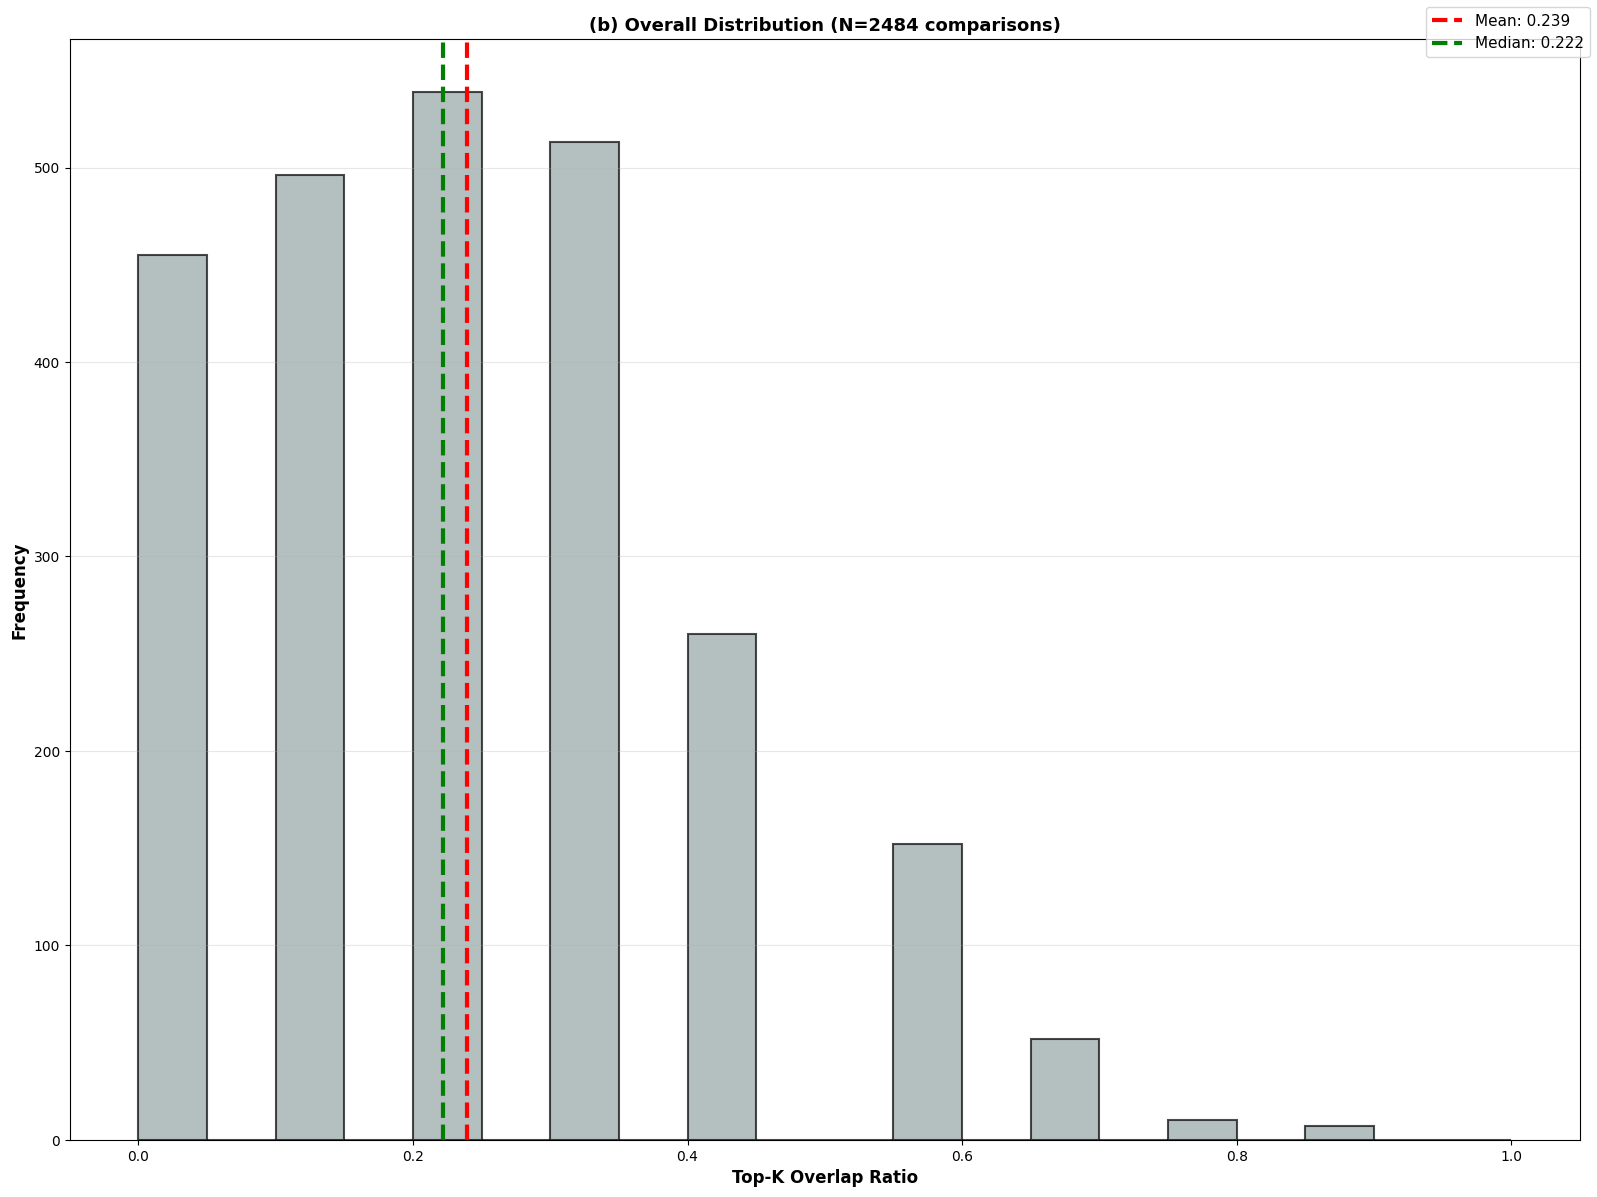

✓ Saved multi-simulation synthetic results to multi_sim_synthetic_results.pdf



In [67]:
# Load pre-cascade data (before cascade_start_idx)
# ============================================================================
# STEP 2: Run multi-simulation synthetic noise analysis
# ============================================================================

multi_synthetic_analyzer = MultiSimulationSyntheticNoiseAnalyzer(
    model=wavenf,
    k=k,
    device='cuda'
)

aggregated_results = multi_synthetic_analyzer.analyze_all_simulations(
    simulation_configs=simulation_configs,
    noise_std=1000.0,              # Adjust based on your data scale
    num_trials=1,               # 5 noise patterns per sequence
    min_sequence_length=5       # At least 5 consecutive normal windows
)

# ============================================================================
# STEP 3: Get results
# ============================================================================

synthetic_mean = aggregated_results['overall_mean']
synthetic_std = aggregated_results['overall_std']


# ============================================================================
# STEP 4: Visualize multi-simulation results
# ============================================================================

plot_multi_sim_synthetic_results(
    aggregated_results,
    multi_synthetic_analyzer.simulation_results,
    save_path='multi_sim_synthetic_results.pdf'
)

